In [38]:
"""Check the output of the UQ"""
import xarray as xr
from utils.paths import *
from utils.analysis import *
import os
import itertools as it
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

casename = 'UQ_default_US-SPR_ICB20TRCNPRDCTCBC'

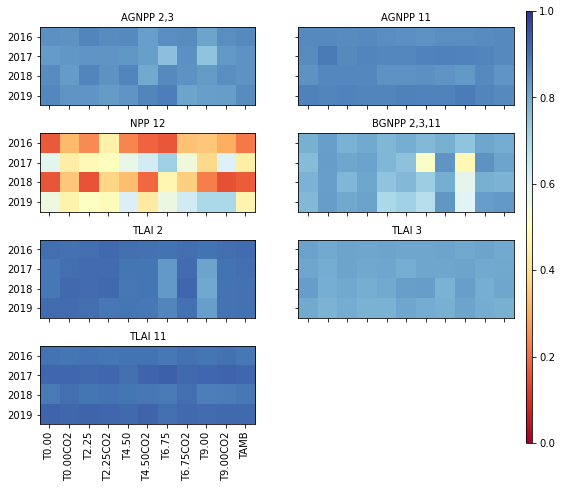

In [43]:
""" MCMC fitstats """

# Read the stats
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'NN_surrogate', 'fitstats.txt')
f = open(filename, 'r')
allstats = [re.split(r'\s+', line.split(': ')[1]) for line in f.read().split('\n') if line[:3] == 'QOI']
allstats = pd.DataFrame([[float(line[0]), float(line[1])] for line in allstats], index = range(len(allstats)), columns = ['R2', 'RMSE'])
f.close()

# Read the column names
postproc_vars = pd.read_csv('./temp/postproc_vars_SPRUCE', sep = r'\s+')
index = postproc_vars.iloc[:, [0, 1, 8, 11]]
index.columns = ['variable', 'year', 'pfts', 'chamber']
allstats.index = pd.MultiIndex.from_frame(index)

# Make the plot
var_and_pft = index[['variable', 'pfts']].drop_duplicates()
fig, axes = plt.subplots(4, 2, figsize = (8.5, 7.5), sharex = True, sharey = True)
count = 0
for _, row in var_and_pft.iterrows():
    ax = axes.flat[count]

    var = row['variable']
    pft = row['pfts']
    ax.set_title(f'{var} {pft}')

    try:
        temp = allstats.loc[(var, slice(None), pft, slice(None)), 'R2']
    except:
        ax.axis('off') # combination doesn't exist
        continue

    temp.index = temp.index.droplevel([0, 2])
    temp = temp.unstack()

    cf = ax.imshow(temp, vmin = 0, vmax = 1., cmap = 'RdYlBu')
    ax.set_xticks(range(temp.shape[1]))
    ax.set_xticklabels(temp.columns)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_yticks(range(temp.shape[0]))
    ax.set_yticklabels(temp.index)

    count += 1
axes.flat[-1].axis('off')
cax = fig.add_axes([0.92, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')